# Data Science Mini Project

### Student Name : Simon V

### Batch : TN-DSB02

### Project Title : Bank Marketing Using Data Science and Machine Learning

### Submission Date : 

----

## 1. Problem Definition 

### 1.1 Business/Real-World Problem Statement
##### Banks conduct marketing compaigns to promote term deposite. Contacting every customer is expensive and inefficient.

##### Objective : Develop a Machine Learning model That predicts whether a customer will subscribe to a term deposit (yes or no)

### 1.2 Project Overview 
##### The goal of this project is to predict whether a customer will subscribe to a bank term deposit based on demographic, financial, and marketing compaign data. The project uses Data Science for data analysis and Machine Learning for prediction, then deploys the model using Docker and publishes the source code on GitHub.

### 1.3 Dataset
#### Dataset name : bank Marketing Dataset
#### Source : UCI Machine Learning Repository

### Dataset Size 
#### Rows : 45,211
#### Columns : 17
#### Target Variable : y


-----

## 2. Data Science Workflow

### 2.1 Data Collection
##### * Download dataset
##### * Load into Python using Pandas
#### Tools :
###### * Python
###### * Pandas
###### * Scipy.io

In [2]:
import pandas as pd
from scipy.io import arff
data, meta = arff.loadarff("phpkIxskf.arff")


In [3]:
df = pd.DataFrame(data)

In [4]:
print(data)

[(58., b'management', b'married', b'tertiary', b'no', 2.143e+03, b'yes', b'no', b'unknown',  5., b'may',  261., 1.,  -1.,  0., b'unknown', b'1')
 (44., b'technician', b'single', b'secondary', b'no', 2.900e+01, b'yes', b'no', b'unknown',  5., b'may',  151., 1.,  -1.,  0., b'unknown', b'1')
 (33., b'entrepreneur', b'married', b'secondary', b'no', 2.000e+00, b'yes', b'yes', b'unknown',  5., b'may',   76., 1.,  -1.,  0., b'unknown', b'1')
 ...
 (72., b'retired', b'married', b'secondary', b'no', 5.715e+03, b'no', b'no', b'cellular', 17., b'nov', 1127., 5., 184.,  3., b'success', b'2')
 (57., b'blue-collar', b'married', b'secondary', b'no', 6.680e+02, b'no', b'no', b'telephone', 17., b'nov',  508., 4.,  -1.,  0., b'unknown', b'1')
 (37., b'entrepreneur', b'married', b'secondary', b'no', 2.971e+03, b'no', b'no', b'cellular', 17., b'nov',  361., 2., 188., 11., b'other', b'1')]


In [5]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58.0,b'management',b'married',b'tertiary',b'no',2143.0,b'yes',b'no',b'unknown',5.0,b'may',261.0,1.0,-1.0,0.0,b'unknown',b'1'
1,44.0,b'technician',b'single',b'secondary',b'no',29.0,b'yes',b'no',b'unknown',5.0,b'may',151.0,1.0,-1.0,0.0,b'unknown',b'1'
2,33.0,b'entrepreneur',b'married',b'secondary',b'no',2.0,b'yes',b'yes',b'unknown',5.0,b'may',76.0,1.0,-1.0,0.0,b'unknown',b'1'
3,47.0,b'blue-collar',b'married',b'unknown',b'no',1506.0,b'yes',b'no',b'unknown',5.0,b'may',92.0,1.0,-1.0,0.0,b'unknown',b'1'
4,33.0,b'unknown',b'single',b'unknown',b'no',1.0,b'no',b'no',b'unknown',5.0,b'may',198.0,1.0,-1.0,0.0,b'unknown',b'1'


## 2.2 Data Understanding

In [6]:
df.shape

(45211, 17)

In [7]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='str')

In [8]:
df.dtypes

V1       float64
V2        object
V3        object
V4        object
V5        object
V6       float64
V7        object
V8        object
V9        object
V10      float64
V11       object
V12      float64
V13      float64
V14      float64
V15      float64
V16       object
Class     object
dtype: object

In [9]:
df.isnull().sum()

V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
V11      0
V12      0
V13      0
V14      0
V15      0
V16      0
Class    0
dtype: int64

In [10]:
df.describe().sum()

V1      45495.554972
V6     145674.037887
V10     45312.128895
V12     51246.690892
V13     45286.861862
V14     46218.326574
V15     45488.883764
dtype: float64

### 2.3 Data Cleaning

##### * Remove duplicates

In [11]:
import numpy as np

In [12]:
df = df.drop_duplicates()

In [13]:
print(df.duplicated().sum())

0


#### * Handle missing values
##### Check missing values

In [14]:
print("Missing value null - Bank Marketing.ipynb:1")
df.isnull().sum()

Missing value null - Bank Marketing.ipynb:1


V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
V11      0
V12      0
V13      0
V14      0
V15      0
V16      0
Class    0
dtype: int64

In [15]:
object_cols = df.select_dtypes(include="object").columns

#### Correct Data Types

In [16]:
df[object_cols] = df[object_cols].astype("string")
print(df.dtypes)

V1       float64
V2        string
V3        string
V4        string
V5        string
V6       float64
V7        string
V8        string
V9        string
V10      float64
V11       string
V12      float64
V13      float64
V14      float64
V15      float64
V16       string
Class     string
dtype: object


#### Remove Invalid Records

In [17]:
if "V6" not in df.columns:
    df = pd.DataFrame(data)
    df[object_cols] = df[object_cols].astype("string")

if "balance" not in df.columns and "V6" in df.columns:
    df["balance"] = df["V6"]
if "duration" not in df.columns and "V12" in df.columns:
    df["duration"] = df["V12"]
df = df[df["V12"] >= 0]
df = df[df["balance"]>=0]
df = df[df["duration"]>=0]
print(df.head())


     V1            V2       V3         V4  V5      V6   V7   V8       V9  V10  \
0  58.0    management  married   tertiary  no  2143.0  yes   no  unknown  5.0   
1  44.0    technician   single  secondary  no    29.0  yes   no  unknown  5.0   
2  33.0  entrepreneur  married  secondary  no     2.0  yes  yes  unknown  5.0   
3  47.0   blue-collar  married    unknown  no  1506.0  yes   no  unknown  5.0   
4  33.0       unknown   single    unknown  no     1.0   no   no  unknown  5.0   

   V11    V12  V13  V14  V15      V16 Class  balance  duration  
0  may  261.0  1.0 -1.0  0.0  unknown     1   2143.0     261.0  
1  may  151.0  1.0 -1.0  0.0  unknown     1     29.0     151.0  
2  may   76.0  1.0 -1.0  0.0  unknown     1      2.0      76.0  
3  may   92.0  1.0 -1.0  0.0  unknown     1   1506.0      92.0  
4  may  198.0  1.0 -1.0  0.0  unknown     1      1.0     198.0  


### 3. Exploratory Data Analysis (EDA)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#####  * Age Distribution (Histogram) : Shows how customer ages are distributed and whether the data is skewed.



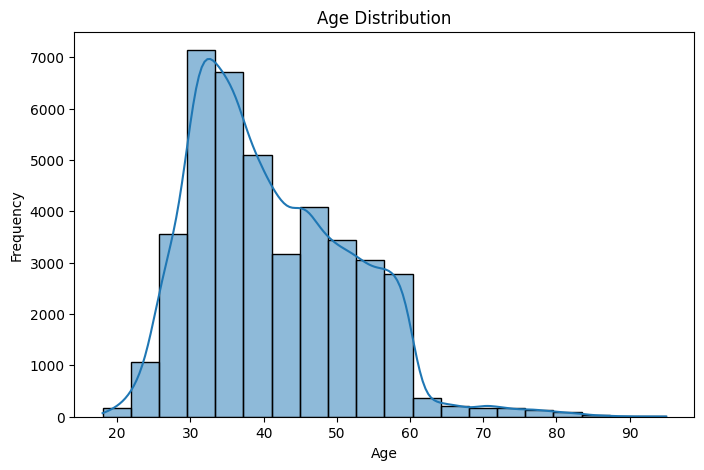

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["V1"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#####  * Job Categories (Count Plot): Displays the number of customers in each occupation.


<Figure size 1200x600 with 0 Axes>

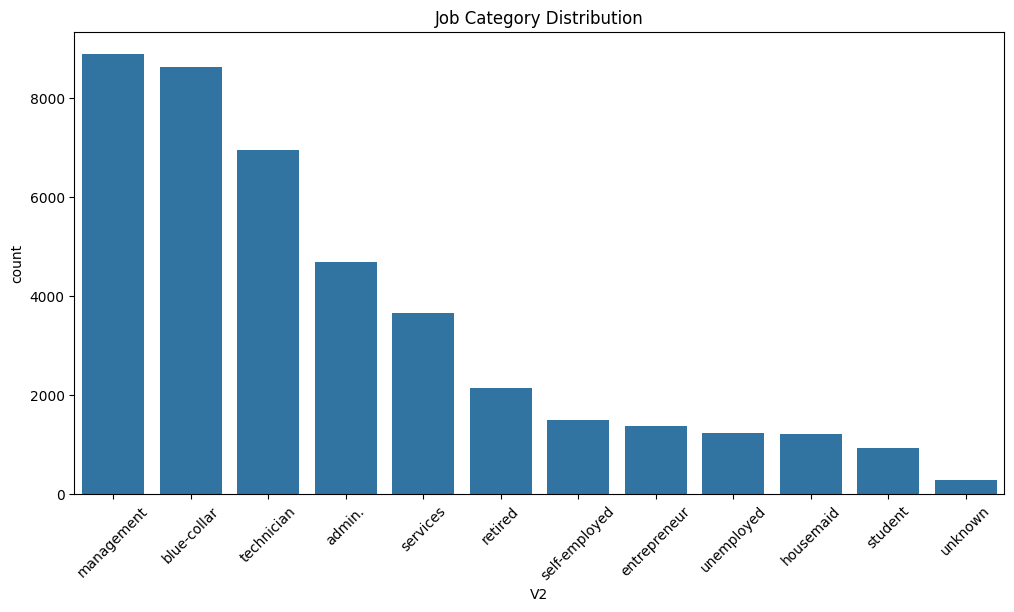

In [20]:
plt.figure(figsize=(12,6))
plt.figure(figsize=(12,6))
sns.countplot(x="V2", data=df, order=df["V2"].value_counts().index)
plt.title("Job Category Distribution")
plt.xticks(rotation=45)
plt.show()


#####  * Loan Status (Count Plot): Compares customers who have personal loans with those who do not.



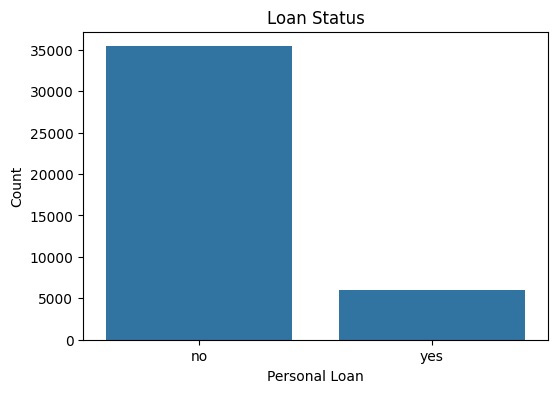

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="V8", data=df)
plt.title("Loan Status")
plt.xlabel("Personal Loan")
plt.ylabel("Count")
plt.show()

#####  * Balance Distribution (Box Plot): Identifies the spread of account balances and detects outliers.

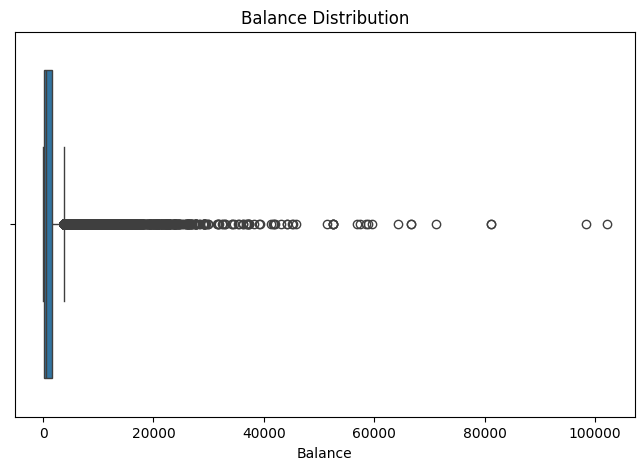

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["balance"])
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.show()

#####  * Target Class Distribution: Shows how many customers subscribed (yes) versus did not subscribe (no).


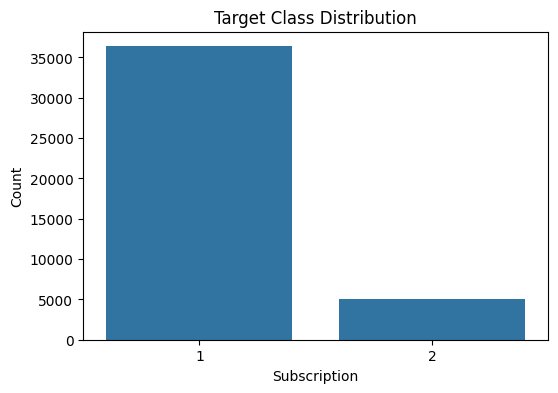

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

##### * Correlation Heatmap: Visualizes relationships between numerical features to identify strong positive or negative correlations.


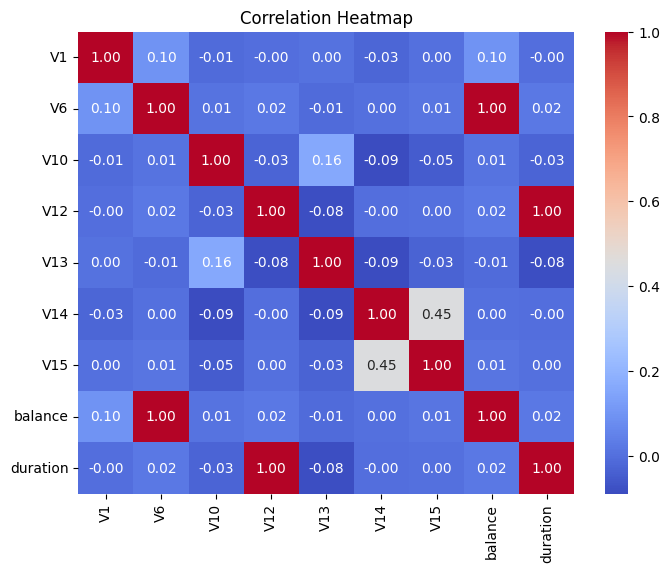

In [24]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##### * Pair Plot: Displays pairwise relationships among important numerical features, with points colored by the target class (y).

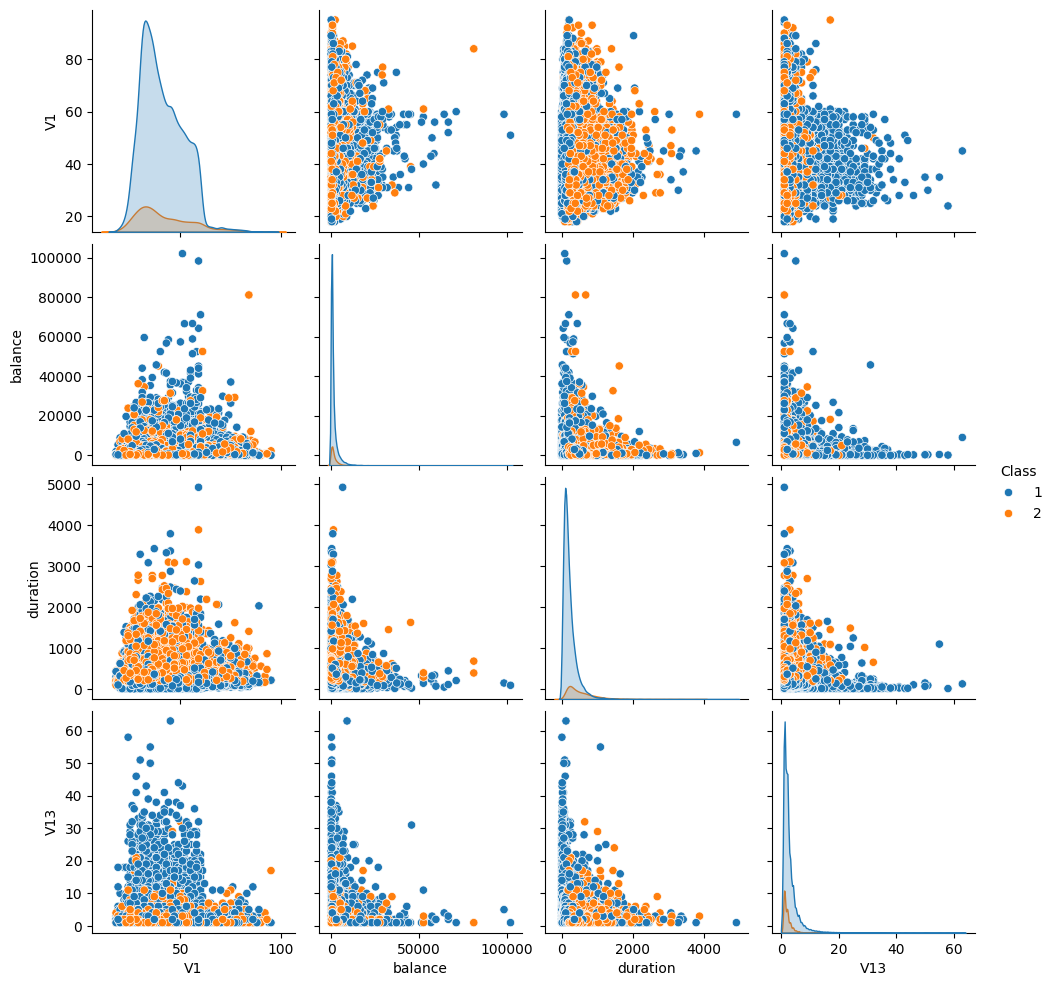

In [25]:
selection_features = ["V1", "balance", "duration", "V13", "Class"]
sns.pairplot(df[selection_features], hue="Class")
plt.show()

## 4. Feature Engineering

In [26]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Label Encoding
#### I used Label Encoding for binary categorical columns such as default, housing, loan, and the target variable y. It converts values like yes/no into 1/0.

In [27]:
le = LabelEncoder()

In [28]:
binary_cols = ["V5", "V14", "V8", "Class"]
for col in binary_cols :
    df[col] = le.fit_transform(df[col])
print(df[binary_cols].head())

   V5  V14  V8  Class
0   0    0   0      0
1   0    0   0      0
2   0    0   1      0
3   0    0   0      0
4   0    0   0      0


#### One-Hot Encoding
##### For categorical columns with multiple categories, such as job, marital, education, contact, month, and poutcome, I used One-Hot Encoding to create separate binary columns. This avoids introducing an artificial order between categories.

In [29]:
multi_cols_mapped = ['V2', 'V3', 'V4', 'V9', 'V11', 'V16']
df = pd.get_dummies(df, columns=multi_cols_mapped, drop_first=True)
print(df.head())

     V1  V5      V6   V7  V8  V10    V12  V13  V14  V15  ...  V11_jul  \
0  58.0   0  2143.0  yes   0  5.0  261.0  1.0    0  0.0  ...    False   
1  44.0   0    29.0  yes   0  5.0  151.0  1.0    0  0.0  ...    False   
2  33.0   0     2.0  yes   1  5.0   76.0  1.0    0  0.0  ...    False   
3  47.0   0  1506.0  yes   0  5.0   92.0  1.0    0  0.0  ...    False   
4  33.0   0     1.0   no   0  5.0  198.0  1.0    0  0.0  ...    False   

   V11_jun  V11_mar  V11_may  V11_nov  V11_oct  V11_sep  V16_other  \
0    False    False     True    False    False    False      False   
1    False    False     True    False    False    False      False   
2    False    False     True    False    False    False      False   
3    False    False     True    False    False    False      False   
4    False    False     True    False    False    False      False   

   V16_success  V16_unknown  
0        False         True  
1        False         True  
2        False         True  
3        False      

#### StandardScaler

##### I applied StandardScaler to numerical features so that they have a mean of 0 and a standard deviation of 1. This is useful for algorithms like Logistic Regression, KNN, and SVM.


In [30]:
Standard_Scaler = StandardScaler()

In [31]:
numerical_cols = ["V1", "balance", "V10", "duration", "V13", "V14", "V15"]
df_standard  = df.copy()
df_standard[numerical_cols] = Standard_Scaler.fit_transform(df_standard[numerical_cols])
print(df_standard[numerical_cols].head())

         V1   balance       V10  duration       V13       V14       V15
0  1.576675  0.200420 -1.295604  0.008853 -0.571368 -0.419136 -0.253037
1  0.272984 -0.474162 -1.295604 -0.417224 -0.571368 -0.419136 -0.253037
2 -0.751345 -0.482778 -1.295604 -0.707731 -0.571368 -0.419136 -0.253037
3  0.552346 -0.002848 -1.295604 -0.645756 -0.571368 -0.419136 -0.253037
4 -0.751345 -0.483097 -1.295604 -0.235173 -0.571368 -0.419136 -0.253037


##### MinMaxScaler
##### I also applied MinMaxScaler, which scales numerical features to a range between 0 and 1. This is helpful for distance-based algorithms such as KNN and some neural network models.


In [32]:
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numerical_cols] = minmax_scaler.fit_transform(df_minmax[numerical_cols])
print(df_minmax[numerical_cols].head())

         V1   balance       V10  duration  V13  V14  V15
0  0.519481  0.020984  0.133333  0.053070  0.0  0.0  0.0
1  0.337662  0.000284  0.133333  0.030704  0.0  0.0  0.0
2  0.194805  0.000020  0.133333  0.015453  0.0  0.0  0.0
3  0.376623  0.014746  0.133333  0.018707  0.0  0.0  0.0
4  0.194805  0.000010  0.133333  0.040260  0.0  0.0  0.0


## 5. Machine Learning Model
#### Since the target variable is Yes or No, this is a supervised binary classification problem. I trained multiple models including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, K-Nearest Neighbors, and Naive Bayes.

### Train-Test Split
##### * Training: 80%
##### * Testing: 20%

#### 6. Model Evaluation
#### I evaluated each model using Accuracy, Precision, Recall, F1-score, ROC-AUC Score, and the Confusion Matrix. I compared the results and selected the best-performing model.


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [34]:
x = df[["duration"]].values
y = df["Class"].values

In [35]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [36]:
model = LogisticRegression(max_iter=1000)
model.fit(x,y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [37]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x,y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [38]:
model = RandomForestClassifier(random_state=42)
model.fit(x,y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [39]:
model = SVC(probability=True, random_state=42)
model.fit(x,y)

c:\Users\SIMON\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [40]:
model = KNeighborsClassifier()
model.fit(x,y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [41]:
model = GaussianNB()
model.fit(x,y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[36366., 5079.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.88,0.12]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.665e-05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 1)","[[221.26], [526.92]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 1)","[[ 43516.26], [150319.89]]"


In [42]:
y_pred = model.predict(x_test)

In [43]:
y_prob = model.predict_proba(x_test)[:1]

In [44]:
y_pred = y_prob

In [45]:
model.score(x_test, y_test)

0.8797201109904693

In [46]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test) if hasattr(model, "predict_proba") else None
accuracy = accuracy_score(y_test, y_pred)


In [47]:
print(accuracy)

0.8797201109904693


In [48]:
precision = precision_score(y_test, y_pred) 

In [49]:
print(precision)

0.5191919191919192


In [50]:
recall = recall_score(y_test, y_pred)

In [51]:
print(recall)

0.2529527559055118


In [52]:
f1 = f1_score(y_test, y_pred)

In [53]:
print(f1)

0.34017207147584383


In [54]:
roc_auc = roc_auc_score(y_test, y_pred)

In [55]:
print(roc_auc)

0.6101144915234971


In [56]:
cm =confusion_matrix(y_test, y_pred)

In [57]:
print(cm)

[[7035  238]
 [ 759  257]]


#### 7. GitHub

##### I used Git for version control and pushed the project to GitHub. The repository includes the source code, Jupyter Notebook, requirements file, Dockerfile, README, and the trained model.

#### 8. Docker Deployment

##### I containerized the application using Docker by creating a Dockerfile, installing the required dependencies, building a Docker image, and running the application inside a Docker container. This makes the application portable and easy to deploy.